In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Global config
DATA_DIR = r"D:\Jacky\Python\ADMM_P2P_Python\data"

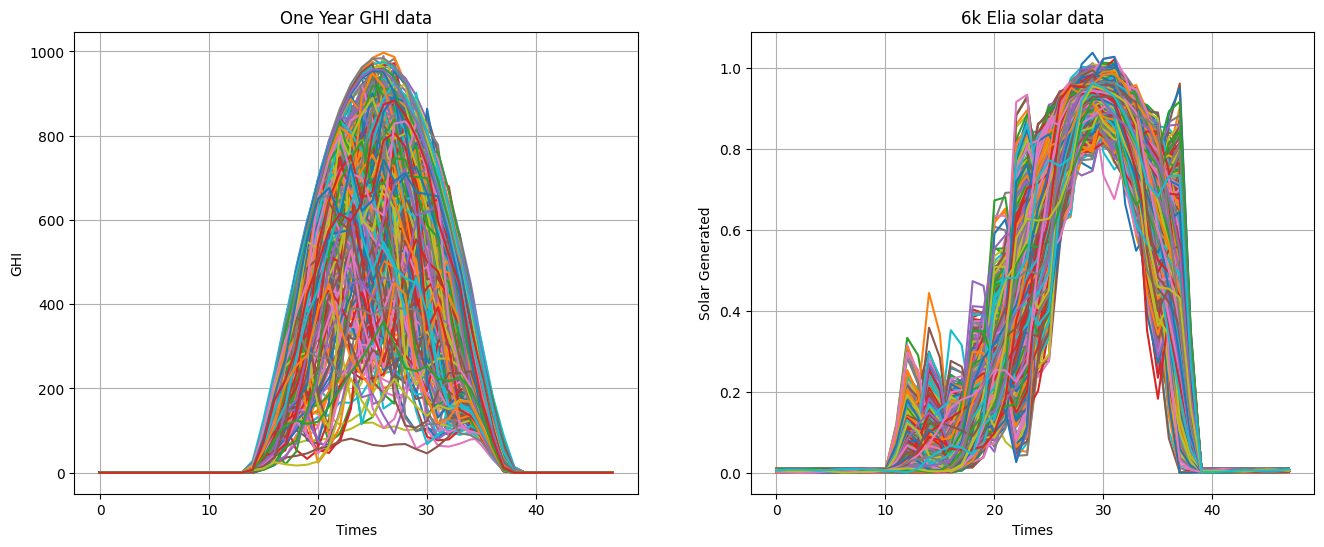

In [2]:
ghi_MUM = pd.read_csv(f"{DATA_DIR}/ghi_Solcast_year_utc8_MUM.csv", header=0).values[:,2].reshape(364,48)
elia_solar = pd.read_csv(f"{DATA_DIR}/Solar_interpolated_6000.csv", header=0).values

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(ghi_MUM.T)
ax[0].set_title(f"One Year GHI data")
ax[0].set_xlabel("Times")
ax[0].set_ylabel("GHI")
ax[0].grid(True)

ax[1].plot(elia_solar.T)
ax[1].set_title(f"6k Elia solar data")
ax[1].set_xlabel("Times")
ax[1].set_ylabel("Solar Generated")
ax[1].grid(True)

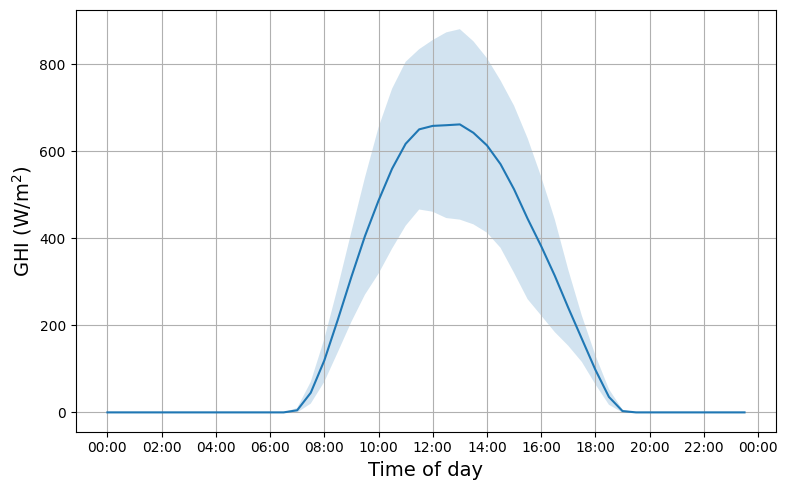

In [12]:
import datetime as dt
import matplotlib.dates as mdates

ghi_MUM = np.array(ghi_MUM, dtype=np.float64)
est = np.mean(ghi_MUM, axis=0)
sd = np.std(ghi_MUM, axis=0)
cis = (est - sd, est + sd)
x = np.arange(ghi_MUM.shape[1])
time_axis = [
    dt.datetime(2000, 1, 1, 0, 0) + dt.timedelta(minutes=30*i)
    for i in range(ghi_MUM.shape[1])
]

fig, ax = plt.subplots(1, 1, figsize=(8, 5))
ax.fill_between(time_axis, cis[0], cis[1], alpha=0.2)
ax.plot(time_axis, est)
# ax.set_title("Mean GHI with Standard Deviation")
ax.set_xlabel("Time of day", fontsize=14)
ax.set_ylabel("GHI (W/m$^2$)", fontsize=14)

ax.grid(True)

# Format x-axis as HH:MM
ax.xaxis.set_major_formatter(mdates.DateFormatter('%H:%M'))
ax.xaxis.set_major_locator(mdates.HourLocator(interval=2))  # every 2 hours

plt.tight_layout()
plt.savefig("solcast_ghi.svg", dpi=300)
plt.show()

# elia_solar = np.array(elia_solar, dtype=np.float64)
# est = np.mean(elia_solar, axis=0)
# sd = np.std(elia_solar, axis=0)
# cis = (est - sd, est + sd)
# x = np.arange(elia_solar.shape[1])

# ax[1].fill_between(x, cis[0], cis[1], alpha=0.2)
# ax[1].plot(x, est)
# ax[1].set_title("Mean Elia Solar with Standard Deviation")
# ax[1].set_xlabel("Time")
# ax[1].set_ylabel("Solar Generated")
# ax[1].grid(True)

In [4]:
# Compute the required power rating for solar panels
# Depending on mean and peak values of elia_solar
elia_mean = np.mean(elia_solar, axis=0)
elia_mean_peak = np.max(elia_mean, axis=0)

solcast_mean = np.mean(ghi_MUM, axis=0)
solcast_mean_peak = np.max(solcast_mean, axis=0)

# E_pv = P_rated * GHI/1000 * 0.5h (kWh)
required_power_rating = elia_mean_peak * 1000 / (solcast_mean_peak * 0.5)
print(f"Required Power Rating for Solar Panels: {round(required_power_rating):.2f} kW per kW peak GHI")

# Assuming PV module: PV-MF125TE4N
pv_module_power = 0.125  # kW
num_modules = round(required_power_rating) / pv_module_power
print(f"Number of Solar Panels Required: {num_modules:.2f}")

Required Power Rating for Solar Panels: 3.00 kW per kW peak GHI
Number of Solar Panels Required: 24.00


Sanity Check: (0.992217032967033, 0.9351735203770802)


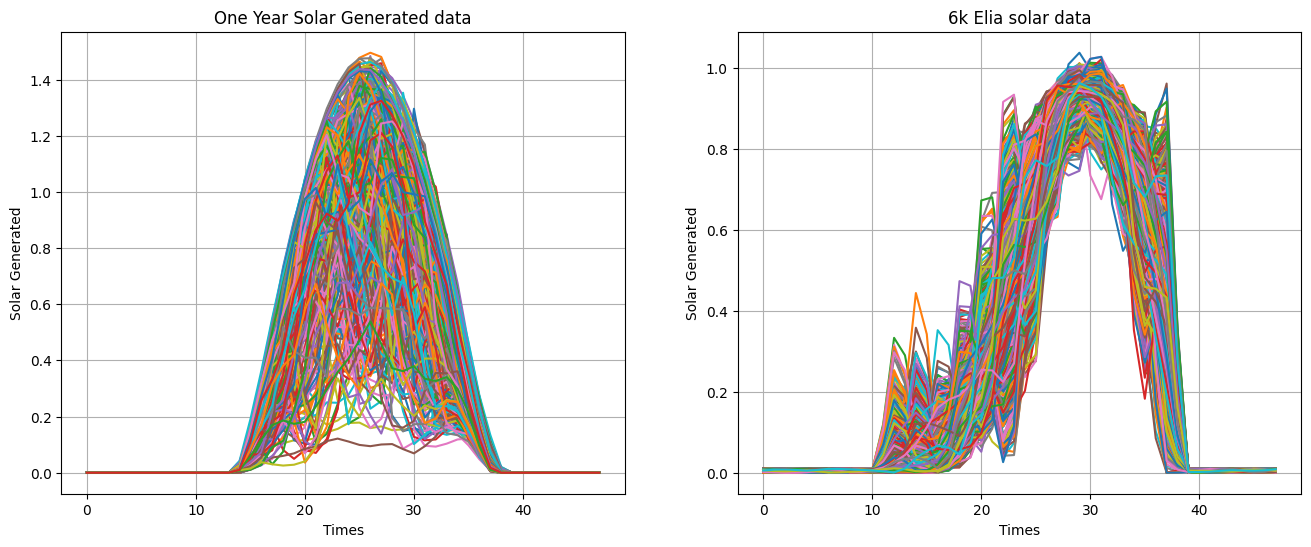

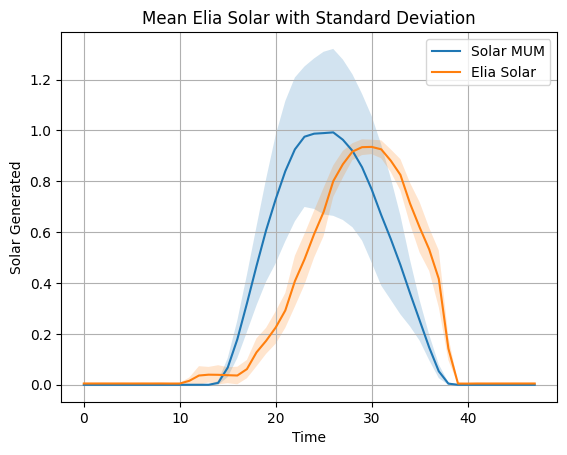

In [5]:
solar_MUM_peak = solcast_mean_peak * num_modules * pv_module_power * 0.5 / 1000  # kWh
print('Sanity Check:', (solar_MUM_peak, elia_mean_peak))

solar_MUM = ghi_MUM * num_modules * pv_module_power * 0.5 / 1000  # kWh

fig, ax = plt.subplots(1, 2, figsize=(16, 6))

ax[0].plot(solar_MUM.T)
ax[0].set_title(f"One Year Solar Generated data")
ax[0].set_xlabel("Times")
ax[0].set_ylabel("Solar Generated")
ax[0].grid(True)

ax[1].plot(elia_solar.T)
ax[1].set_title(f"6k Elia solar data")
ax[1].set_xlabel("Times")
ax[1].set_ylabel("Solar Generated")
ax[1].grid(True)

solar_MUM = np.array(solar_MUM, dtype=np.float64)
est = np.mean(solar_MUM, axis=0)
sd = np.std(solar_MUM, axis=0)
cis = (est - sd, est + sd)
x = np.arange(solar_MUM.shape[1])

fig, ax = plt.subplots(1, 1)
ax.fill_between(x, cis[0], cis[1], alpha=0.2)
ax.plot(x, est, label='Solar MUM')

elia_solar = np.array(elia_solar, dtype=np.float64)
est = np.mean(elia_solar, axis=0)
sd = np.std(elia_solar, axis=0)
cis = (est - sd, est + sd)
x = np.arange(elia_solar.shape[1])

ax.fill_between(x, cis[0], cis[1], alpha=0.2)
ax.plot(x, est, label='Elia Solar')
ax.set_title("Mean Elia Solar with Standard Deviation")
ax.set_xlabel("Time")
ax.set_ylabel("Solar Generated")
ax.grid(True)
ax.legend()

In [6]:
solar_df = pd.DataFrame(solar_MUM, columns=[f"x{i}" for i in range(solar_MUM.shape[1])])
solar_df.to_csv(f"{DATA_DIR}/Solar_Solcast_year_utc8_MUM.csv", index=False)  # header included by default